In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fractions import Fraction
from math import gcd, log, ceil

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import UnitaryGate, QFT
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
import time


def build_mod_mult_unitary(k, N, n_bits):
    dim = 2**n_bits
    U = np.zeros((dim, dim))
    for x in range(dim):
        if x == 0:
            U[0][0] = 1
        elif x < N and gcd(x, N) == 1:
            y = (x * k) % N
            U[y][x] = 1
        else:
            U[x][x] = 1
    return U


def build_shor_circuit(N, a, num_control, num_target):
    control = QuantumRegister(num_control, name='Counting')
    target  = QuantumRegister(num_target,  name='Target')
    output  = ClassicalRegister(num_control, name='output')
    circuit = QuantumCircuit(control, target, output)

    circuit.x(num_control)
    for k in range(num_control):
        circuit.h(k)
    circuit.barrier()

    n_mod_mults = 0
    for k in range(num_control):
        power = pow(a, 2**k, N)
        if power == 1:
            continue
        U      = build_mod_mult_unitary(power, N, num_target)
        gate   = UnitaryGate(U)
        gate.name = f'M_{power}'
        c_gate = gate.control()
        circuit.compose(c_gate,
                        qubits=[k] + list(range(num_control, num_control + num_target)),
                        inplace=True)
        n_mod_mults += 1

    circuit.barrier()
    circuit.compose(QFT(num_control, inverse=True), qubits=control, inplace=True)
    circuit.barrier()
    circuit.measure(control, output)

    return circuit, n_mod_mults

In [2]:
# ── Connect to IBM Quantum ────────────────────────────────────────────────
# Token already saved from N=15 run — no need to call save_account again

service = QiskitRuntimeService(channel='ibm_quantum_platform')
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=15)

print(f'Connected to:     {backend.name}')
print(f'Qubits available: {backend.num_qubits}')

Connected to:     ibm_fez
Qubits available: 156


In [3]:
# ── Build circuit for N=21, a=2 ───────────────────────────────────────────
N           = 21
a           = 2
num_target  = ceil(log(N, 2))   # 5 qubits
num_control = 2 * num_target    # 10 qubits

print(f"Building Shor's circuit: N={N}, a={a}")
print(f'Counting qubits: {num_control}')
print(f'Target qubits:   {num_target}')
print(f'Total qubits:    {num_control + num_target}')

print('\nCounting qubit → Controlled multiplication:')
for k in range(num_control):
    power = pow(a, 2**k, N)
    skip  = ' (skip: identity)' if power == 1 else ''
    print(f'  Qubit {k}: a^(2^{k}) mod {N} = {a}^{2**k} mod {N} = {power}{skip}')

circuit, n_mults = build_shor_circuit(N, a, num_control, num_target)
print(f'\nControlled multiplications applied: {n_mults}')

Building Shor's circuit: N=21, a=2
Counting qubits: 10
Target qubits:   5
Total qubits:    15

Counting qubit → Controlled multiplication:
  Qubit 0: a^(2^0) mod 21 = 2^1 mod 21 = 2
  Qubit 1: a^(2^1) mod 21 = 2^2 mod 21 = 4
  Qubit 2: a^(2^2) mod 21 = 2^4 mod 21 = 16
  Qubit 3: a^(2^3) mod 21 = 2^8 mod 21 = 4
  Qubit 4: a^(2^4) mod 21 = 2^16 mod 21 = 16
  Qubit 5: a^(2^5) mod 21 = 2^32 mod 21 = 4
  Qubit 6: a^(2^6) mod 21 = 2^64 mod 21 = 16
  Qubit 7: a^(2^7) mod 21 = 2^128 mod 21 = 4
  Qubit 8: a^(2^8) mod 21 = 2^256 mod 21 = 16
  Qubit 9: a^(2^9) mod 21 = 2^512 mod 21 = 4

Controlled multiplications applied: 10


C:\Users\User\AppData\Local\Temp\ipykernel_37076\1305336897.py:54: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  circuit.compose(QFT(num_control, inverse=True), qubits=control, inplace=True)


In [4]:
# ── Transpile for the real device ─────────────────────────────────────────
# N=21 has ~26,737 gates and depth ~19,699 in simulation.
# After transpilation for hardware (SWAP routing etc.) this will be even larger.
# IBM Heron supports ~5,000 gates — N=21 is ~5x over this limit.
# Results will likely be pure noise, but this is a valid experimental finding.

pm               = generate_preset_pass_manager(backend=backend, optimization_level=1)
compiled_circuit = pm.run(circuit)

total_gates = sum(compiled_circuit.count_ops().values())
print(f'Transpiled for:  {backend.name}')
print(f'Total gates:     {total_gates}')
print(f'Circuit depth:   {compiled_circuit.depth()}')
print(f'Gate breakdown:  {dict(compiled_circuit.count_ops())}')
print(f'\nNote: IBM Heron supports ~5,000 gates. N=21 exceeds this significantly.')

Transpiled for:  ibm_fez
Total gates:     132989
Circuit depth:   82191
Gate breakdown:  {'sx': 59959, 'rz': 47220, 'cz': 25796, 'measure': 10, 'barrier': 3, 'x': 1}

Note: IBM Heron supports ~5,000 gates. N=21 exceeds this significantly.


In [5]:
# ── Submit job ────────────────────────────────────────────────────────────
shots   = 1024
sampler = SamplerV2(backend)
job     = sampler.run([compiled_circuit], shots=shots)

print(f'Job submitted!')
print(f'Job ID:  {job.job_id()}')
print(f'Status:  {job.status()}')
print(f'Shots:   {shots}')

Job submitted!
Job ID:  d6rho0fr88ds73ddhrrg
Status:  QUEUED
Shots:   1024


In [6]:
# ── Retrieve results ──────────────────────────────────────────────────────
# If session disconnected:
#   job = service.job('YOUR_JOB_ID_HERE')

result = job.result()
counts = result[0].data.output.get_counts()

print(f'Job complete!')
print(f'Unique outcomes: {len(counts)}')
print(f'Total shots:     {sum(counts.values())}')
print(f'\nTop 10 results:')
for bs, cnt in sorted(counts.items(), key=lambda x: -x[1])[:10]:
    print(f'  {bs}  (decimal {int(bs, 2):4d})  →  {cnt} shots  ({100*cnt/shots:.1f}%)')

Job complete!
Unique outcomes: 612
Total shots:     1024

Top 10 results:
  0111000000  (decimal  448)  →  6 shots  (0.6%)
  0000100010  (decimal   34)  →  5 shots  (0.5%)
  0101000110  (decimal  326)  →  5 shots  (0.5%)
  0010001100  (decimal  140)  →  5 shots  (0.5%)
  0101000000  (decimal  320)  →  5 shots  (0.5%)
  0000011010  (decimal   26)  →  4 shots  (0.4%)
  0110011000  (decimal  408)  →  4 shots  (0.4%)
  1001101000  (decimal  616)  →  4 shots  (0.4%)
  1000100000  (decimal  544)  →  4 shots  (0.4%)
  1000101001  (decimal  553)  →  4 shots  (0.4%)


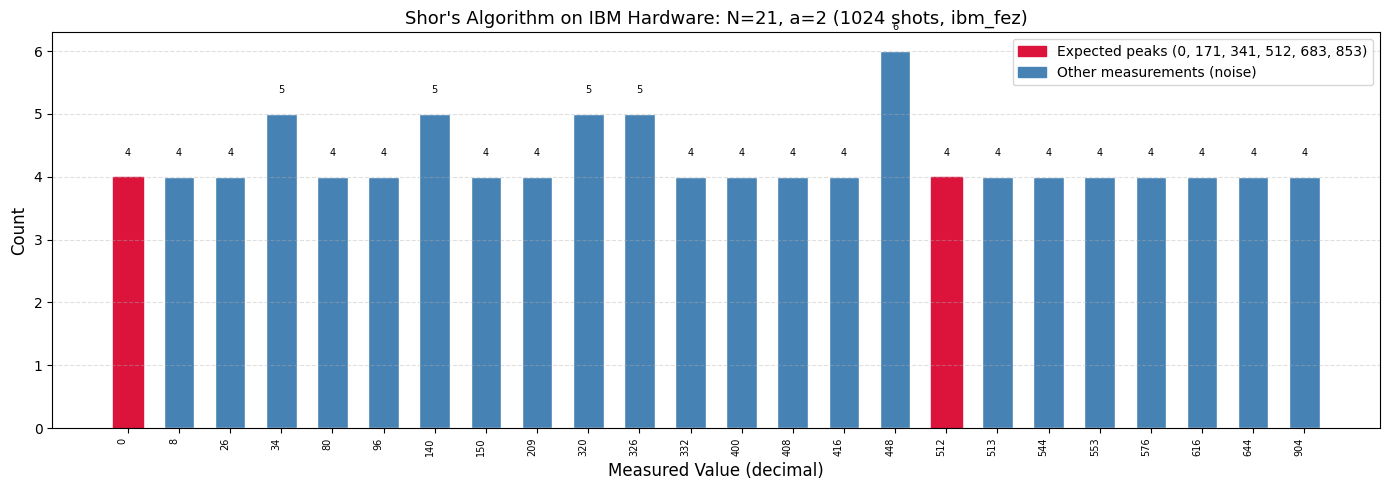

In [7]:
# ── Histogram ─────────────────────────────────────────────────────────────
# N=21 ideal peaks are at multiples of 1024/6 ≈ {0, 171, 341, 512, 683, 853}

decimal_counts  = {int(k, 2): v for k, v in counts.items()}
filtered_counts = {k: v for k, v in sorted(decimal_counts.items()) if v > 3}

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(range(len(filtered_counts)),
              list(filtered_counts.values()),
              color='steelblue', edgecolor='white', width=0.6)

for bar, count in zip(bars, filtered_counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(count), ha='center', va='bottom', fontsize=7)

# Highlight expected peaks from ideal simulation
expected = {0, 171, 341, 512, 683, 853}
keys     = list(filtered_counts.keys())
for i, k in enumerate(keys):
    if k in expected:
        bars[i].set_color('crimson')

ax.set_xticks(range(len(filtered_counts)))
ax.set_xticklabels([str(k) for k in keys], rotation=90, ha='right', fontsize=7)
ax.set_xlabel('Measured Value (decimal)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title(
    f"Shor's Algorithm on IBM Hardware: N={N}, a={a} ({shots} shots, {backend.name})",
    fontsize=13)
ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color='crimson',   label='Expected peaks (0, 171, 341, 512, 683, 853)'),
    plt.Rectangle((0,0),1,1, color='steelblue', label='Other measurements (noise)'),
], fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [8]:
# ── Period extraction and factoring ──────────────────────────────────────
rows_period   = []
success_shots = 0

for bitstring in sorted(counts, key=lambda x: counts[x], reverse=True):
    count   = counts[bitstring]
    decimal = int(bitstring, 2)
    phase   = decimal / (2**num_control)

    frac  = Fraction(phase).limit_denominator(N)
    r     = frac.denominator
    valid = r > 1 and pow(a, r, N) == 1

    factors = ''
    if valid and r % 2 == 0:
        x = pow(a, r // 2, N)
        if x != N - 1:
            f1, f2 = gcd(x - 1, N), gcd(x + 1, N)
            if 1 < f1 < N:
                factors = f'{f1} x {N // f1}'
                success_shots += count
            elif 1 < f2 < N:
                factors = f'{f2} x {N // f2}'
                success_shots += count

    rows_period.append([
        f'{phase:.4f}', f'{frac.numerator}/{frac.denominator}',
        r, 'Yes' if valid else 'No', count,
        factors if factors else '-'
    ])

print(f'Period extraction and factoring for N={N}, a={a}:')
df = pd.DataFrame(rows_period[:15],
    columns=['Phase', 'Fraction', 'Guess for r', 'Valid', 'Count', 'Factors'])
print(df.to_string(index=False))

print(f'\nSuccess rate: {100*success_shots/shots:.1f}%  ({success_shots}/{shots} shots)')
if success_shots > 0:
    print(f'Factors found: 3 x 7 = 21  ✓')
    print(f'Avg shots to first success: {round(shots / success_shots)}')
else:
    print('No successful factorisation.')
    print('Expected — circuit depth far exceeds hardware coherence limits.')

Period extraction and factoring for N=21, a=2:
 Phase Fraction  Guess for r Valid  Count Factors
0.4375     7/16           16    No      6       -
0.0332     1/21           21    No      5       -
0.3184     6/19           19    No      5       -
0.1367     2/15           15    No      5       -
0.3125     5/16           16    No      5       -
0.0254     1/21           21    No      4       -
0.3984      2/5            5    No      4       -
0.6016      3/5            5    No      4       -
0.5312     9/17           17    No      4       -
0.5400     7/13           13    No      4       -
0.3906     7/18           18   Yes      4   7 x 3
0.5010      1/2            2    No      4       -
0.3242     6/19           19    No      4       -
0.2041      1/5            5    No      4       -
0.0781     1/13           13    No      4       -

Success rate: 4.1%  (42/1024 shots)
Factors found: 3 x 7 = 21  ✓
Avg shots to first success: 24


In [9]:
# ── Comparison summary ────────────────────────────────────────────────────
print('N=21 Hardware vs Simulator comparison:')
print(f'  Unique outcomes:  {len(counts)} / 1024  (simulator: 6)')
print(f'  Top probability:  {100*max(counts.values())/shots:.1f}%  (simulator: ~16.7%)')
print(f'  Success rate:     {100*success_shots/shots:.1f}%  (simulator: ~32%)')
print(f'  Factors found:    {"3 x 7 = 21" if success_shots > 0 else "None"}  (simulator: 3 x 7 = 21)')

N=21 Hardware vs Simulator comparison:
  Unique outcomes:  612 / 1024  (simulator: 6)
  Top probability:  0.6%  (simulator: ~16.7%)
  Success rate:     4.1%  (simulator: ~32%)
  Factors found:    3 x 7 = 21  (simulator: 3 x 7 = 21)
